In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_path = "/content/drive/MyDrive/443"

print(os.listdir(base_path))

['bank-data.zip', 'Archive.zip']


In [3]:
import zipfile
import os

archive_path = "/content/drive/MyDrive/443/Archive.zip"

with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    zip_ref.extractall("/content/Archive")

print("Archive.zip extracted successfully!")

Archive.zip extracted successfully!


In [4]:
print(os.listdir("/content/Archive"))

['train', 'test', '__MACOSX', 'val']


In [5]:
train_dir = "/content/Archive/train"
val_dir = "/content/Archive/val"
test_dir = "/content/Archive/test"

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: /content/Archive/train
Validation: /content/Archive/val
Test: /content/Archive/test


In [6]:
import os

print("Train folders:", os.listdir(train_dir))
print("Validation folders:", os.listdir(val_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['NORMAL', '.DS_Store', 'PNEUMONIA']
Validation folders: ['NORMAL', 'PNEUMONIA']
Test folders: ['NORMAL', '.DS_Store', 'PNEUMONIA']


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Image preprocessing ready!")

Image preprocessing ready!


In [9]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [10]:
print("Class indices:", train_data.class_indices)

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [11]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

print("CNN model created successfully!")

CNN model created successfully!


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.8714 - loss: 0.3119 - val_accuracy: 0.7500 - val_loss: 0.5647
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 163s 995ms/step - accuracy: 0.9500 - loss: 0.1328 - val_accuracy: 0.9375 - val_loss: 0.1779
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9634 - loss: 0.0991 - val_accuracy: 1.0000 - val_loss: 0.1069
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.9697 - loss: 0.0886 - val_accuracy: 0.9375 - val_loss: 0.1590
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 162s 993ms/step - accuracy: 0.9739 - loss: 0.0698 - val_accuracy: 1.0000 - val_loss: 0.0675
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9781 - loss: 0.0623 - val_accuracy: 1.0000 - val_loss: 0.1054
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.9843 - loss: 0.0484 - val_accuracy: 0.9375 - val_loss: 0.1219
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9820 - loss: 0.0507 - va

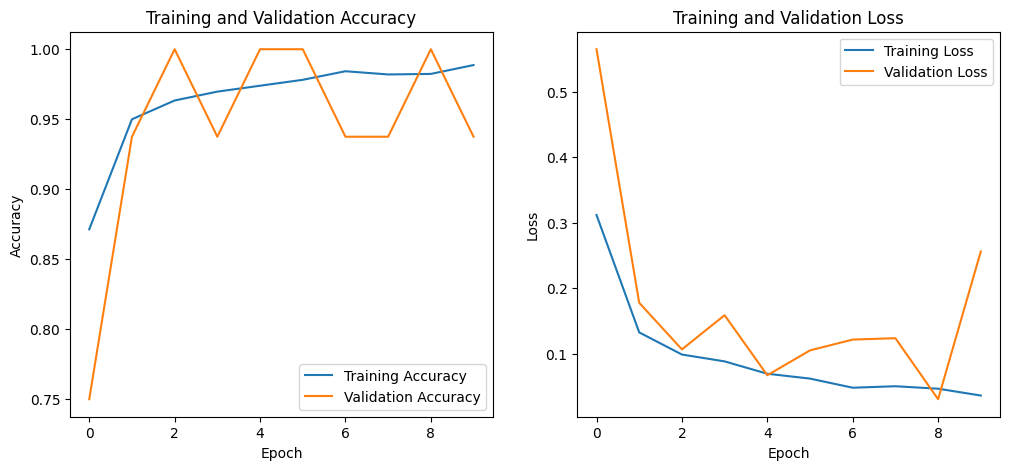

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 417ms/step - accuracy: 0.7196 - loss: 1.9527
Test Accuracy: 0.7195512652397156
Test Loss: 1.952739953994751


In [17]:
from sklearn.metrics import classification_report

test_data.reset()

predictions = model.predict(test_data)

y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_data.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 342ms/step
              precision    recall  f1-score   support

      NORMAL       0.97      0.26      0.41       234
   PNEUMONIA       0.69      0.99      0.82       390

    accuracy                           0.72       624
   macro avg       0.83      0.63      0.61       624
weighted avg       0.80      0.72      0.66       624



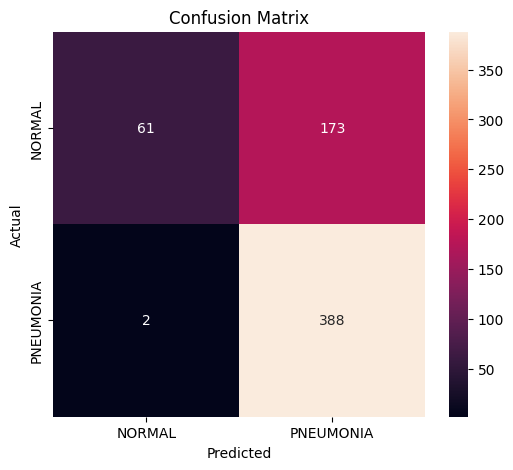

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
model.save('/content/chest_xray_cnn_model.keras')

print("Model saved successfully!")

Model saved successfully!
